# Basic correlations

In [1]:
import pandas as pd

def load_data(drop_columns=None):
    real_x_train = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/real_X_train.csv")
    random_x_train = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/random_X_train.csv")
    shuffle_x_train = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/shuffle_X_train.csv")

    real_x_val = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/real_X_val.csv")
    random_x_val = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/random_X_val.csv")
    shuffle_x_val = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/shuffle_X_val.csv")

    real_y_train = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/real_y_train.csv")
    real_y_val = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/real_y_val.csv")

    real_train = real_x_train.merge(real_y_train, on="complex_filename")
    real_train.set_index("complex_filename", inplace=True)
    real_train.drop(columns=["Unnamed: 0", "complex_filename.1"], inplace=True)
    if drop_columns:
        real_train.drop(columns=drop_columns, inplace=True)
    real_val = real_x_val.merge(real_y_val, on="complex_filename")
    real_train.head()
    return real_train, real_val, random_x_train, random_x_val, shuffle_x_train, shuffle_x_val

real_train, real_val, random_x_train, random_x_val, shuffle_x_train, shuffle_x_val = load_data()

print(len(real_train), len(real_val), len(random_x_train), len(random_x_val), len(shuffle_x_train), len(shuffle_x_val))
print("regression", real_train.shape[0] + real_val.shape[0])
print("classification", real_train.shape[0] + real_val.shape[0] + random_x_train.shape[0] + random_x_val.shape[0] + shuffle_x_train.shape[0] + shuffle_x_val.shape[0])

444 111 170 43 208 53
regression 555
classification 1029


<Axes: xlabel='None'>

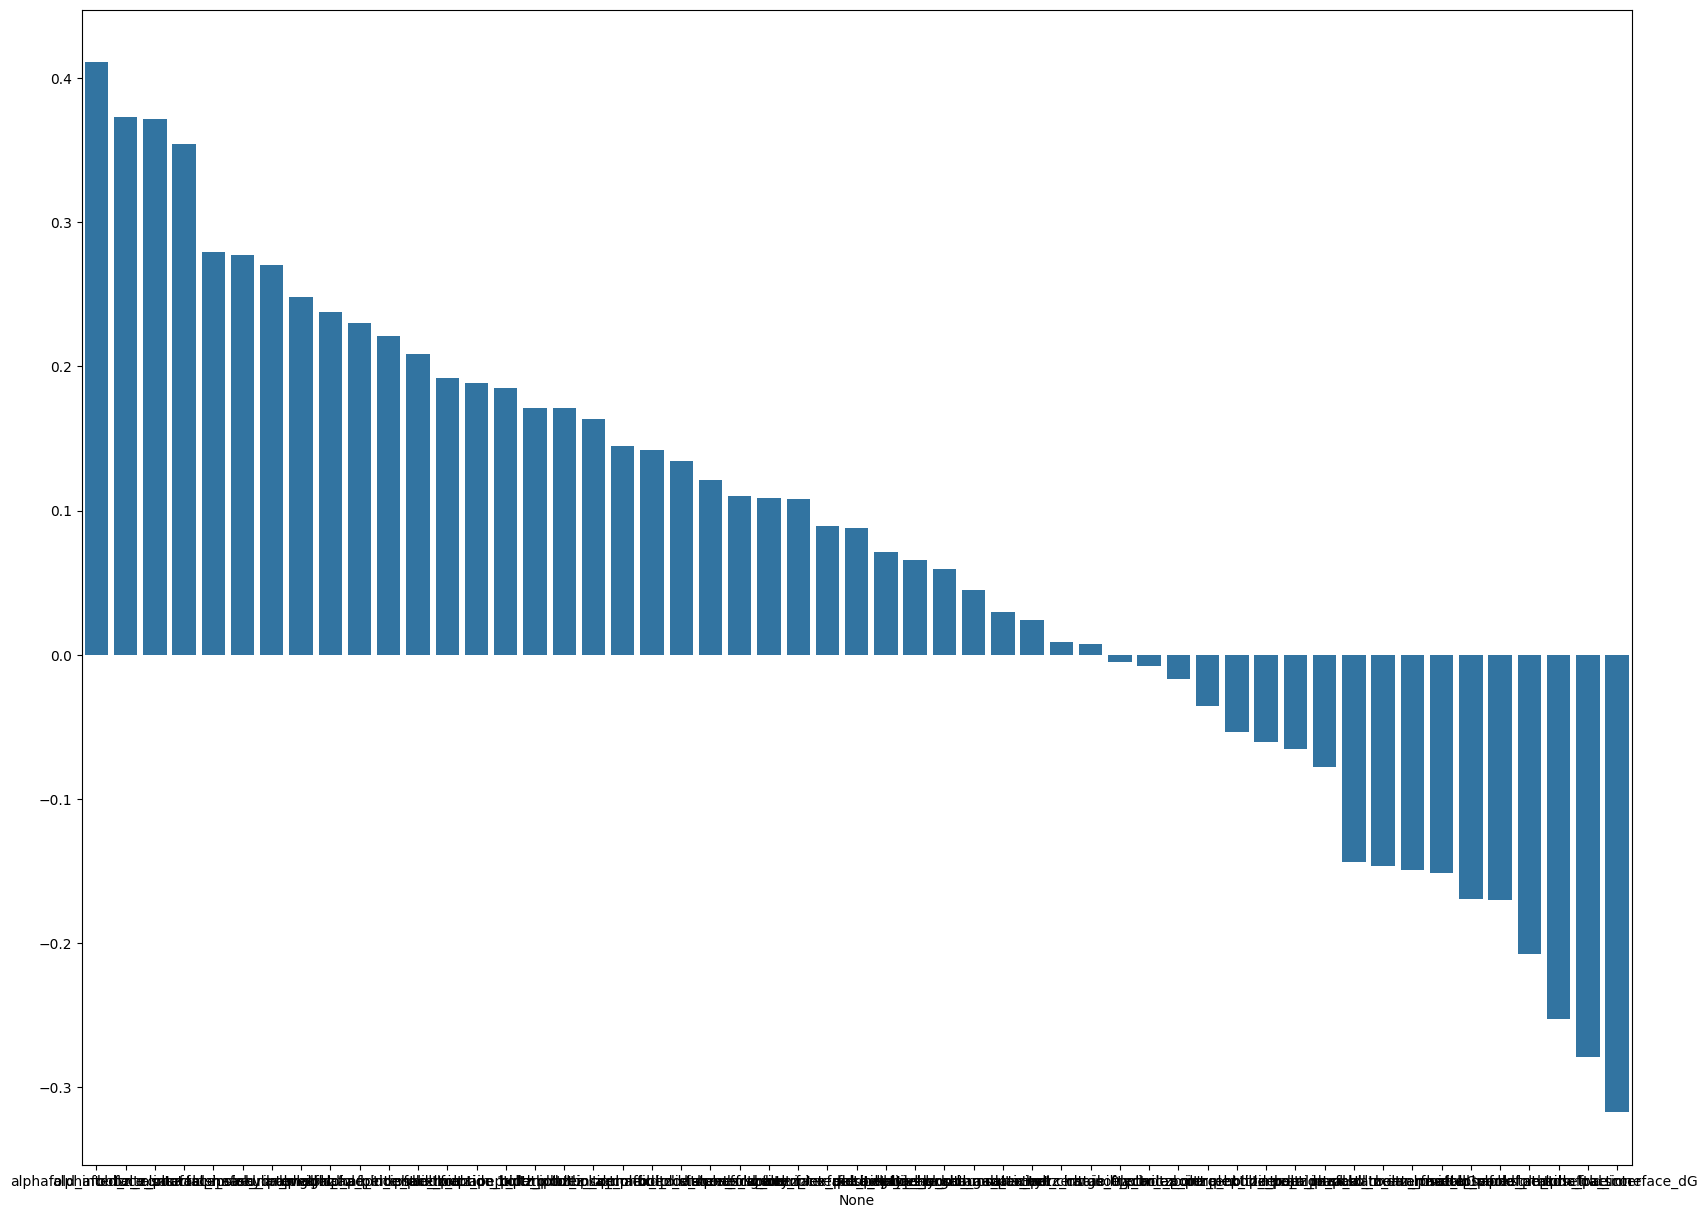

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

plt.figure(figsize=(20, 15))
df_corr = real_train.corr()
pKd_corr = df_corr["pKd"].sort_values(ascending=False)
pKd_corr = pKd_corr.drop(["pKd", "boltz_ligand_iptm", "boltz_complex_pde"])

sns.barplot(y=pKd_corr.values, x=pKd_corr.index)

# Regression fit

In [4]:
def load_regression_data():
    base_dirs = [
        "/home/er8813ha/immunopeptides/plots_v2_both/regression/",
        "/home/er8813ha/immunopeptides/plots_v2_boltz/regression/",
        "/home/er8813ha/immunopeptides/plots_v2_alphafold/regression/"
    ]
    train_regression_predictions = []
    val_regression_predictions = []
    regression_scaling_parameters = []
    symbolic_equations = []
    for base_dir in base_dirs:
        train_regression_predictions_temp = pd.read_csv(base_dir + "train_predictions.csv")
        val_regression_predictions_temp = pd.read_csv(base_dir + "val_predictions.csv")
        regression_scaling_parameters_temp = pd.read_csv(base_dir + "scaling_params.csv")
        symbolic_equations_temp = pd.read_csv(base_dir + "symbolic_regression_all_equations.csv")
        train_regression_predictions_temp["data_type"] = base_dir.split("/")[-3].split("_v2_")[-1]
        val_regression_predictions_temp["data_type"] = base_dir.split("/")[-3].split("_v2_")[-1]
        regression_scaling_parameters_temp["data_type"] = base_dir.split("/")[-3].split("_v2_")[-1]
        symbolic_equations_temp["data_type"] = base_dir.split("/")[-3].split("_v2_")[-1]

        train_regression_predictions.append(train_regression_predictions_temp)
        val_regression_predictions.append(val_regression_predictions_temp)
        regression_scaling_parameters.append(regression_scaling_parameters_temp)
        symbolic_equations.append(symbolic_equations_temp)

    train_regression_predictions = pd.concat(train_regression_predictions, ignore_index=True)
    val_regression_predictions = pd.concat(val_regression_predictions, ignore_index=True)
    regression_scaling_parameters = pd.concat(regression_scaling_parameters, ignore_index=True)
    symbolic_equations = pd.concat(symbolic_equations, ignore_index=True)

    return train_regression_predictions, val_regression_predictions, regression_scaling_parameters, symbolic_equations

train_regression_predictions, val_regression_predictions, regression_scaling_parameters, symbolic_equations = load_regression_data()
regression_scaling_parameters

,Unnamed: 0,mean,std,min,max,data_type
0,alphafold_iptm,0.760023,0.198000,0.040000,0.970000,both
1,alphafold_rosetta_score,-322.740349,297.181321,-1060.764822,845.380246,both
2,alphafold_interface_sasa,1520.322709,577.770405,523.658512,3407.262088,both
3,alphafold_interface_dG,-42.442036,29.234520,-117.400235,324.226461,both
4,alphafold_interface_delta_hbond_unsat,6.626126,5.199830,0.000000,31.000000,both
...,...,...,...,...,...,...
115,negatively_charged_aa_percent,0.123476,0.125664,0.000000,0.684211,alphafold
116,delta_net_charge_frac,0.053582,0.214254,-0.684211,0.750000,alphafold
117,uHrel,0.284400,0.155762,0.011677,0.766569,alphafold
118,alphafold_ipsae_max,0.532314,0.267605,0.000000,0.925535,alphafold


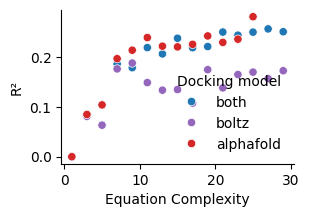

In [ ]:
plt.figure(figsize=(3,2))
sns.scatterplot(symbolic_equations, x="complexity", y="val_r2",  hue="data_type", palette=["tab:blue", "tab:purple", "tab:red"])
plt.xlabel("Equation Complexity")
plt.ylabel("R²")
sns.despine()
plt.legend(title="Docking model", loc='lower right', frameon=False)
#plt.savefig("./plots/v2_regression_equation_complexity_vs_val_r2.svg", dpi=300, bbox_inches='tight')

In [11]:
symbolic_equations.sort_values("val_r2", ascending=False)[["data_type", "complexity", "equation"]].values

array([['alphafold', 25,
        '1.9044503*alphafold_distance_score*(alphafold_interface_peptide_plddt + instability_index)*(alphafold_interface_sasa - alphafold_packstat + hydrophobic_aa_percent*(hydrophobic_aa_percent + uHrel)) + 1.9044503*alphafold_interface_sasa + alphafold_iptm + alphafold_packstat + 3.7507498'],
       ['both', 27,
        '1.51808385512659*boltz_chain_1_ptm*boltz_peptide_plddt*(alphafold_iptm + boltz_distance_score)*(boltz_interface_sasa - turn_fraction + (alphafold_iptm + intra_boltz_mean_rmsd)*(hydrophobic_aa_percent + intra_boltz_mean_rmsd)) + boltz_chain_1_ptm + 1.51808385512659*boltz_interface_sasa + 4.12975433122228'],
       ['both', 29,
        '1.44319511853683*boltz_chain_1_ptm*boltz_peptide_plddt*(alphafold_iptm + boltz_distance_score + intra_boltz_mean_rmsd)*(boltz_interface_sasa - turn_fraction + (alphafold_iptm + intra_boltz_mean_rmsd)*(hydrophobic_aa_percent + intra_boltz_mean_rmsd)) + boltz_chain_1_ptm + 1.44319511853683*boltz_interface_sasa + 4

In [12]:
regression_equation = '1.9044503*alphafold_distance_score*(alphafold_interface_peptide_plddt + instability_index)*(alphafold_interface_sasa - alphafold_packstat + hydrophobic_aa_percent*(hydrophobic_aa_percent + uHrel)) + 1.9044503*alphafold_interface_sasa + alphafold_iptm + alphafold_packstat + 3.7507498'#'1.38143251097807*boltz_chain_1_ptm + 1.38143251097807*boltz_interface_sasa + 1.38143251097807*boltz_peptide_plddt*(alphafold_iptm + boltz_distance_score)*(boltz_interface_sasa - turn_fraction + (alphafold_iptm + intra_boltz_mean_rmsd)*(hydrophobic_aa_percent + intra_boltz_mean_rmsd)) + 3.82578312545652'

In [13]:
def symbolic_predict(df, scaling_parameters, equation='3.6232204*boltz_chain_1_ptm - boltz_interface_dG + 3.6232204*boltz_interface_sasa + 2.24350459347672'):
    """ Scale using parameters and min-max then predict using symbolic equation """
    df = df.copy()
    for _, row in scaling_parameters.iterrows():
        feature = row['Unnamed: 0']
        min_val = row['min']
        max_val = row['max']
        df[feature] = (df[feature] - min_val) / (max_val - min_val)
    features = df.columns.tolist()
    symbolic_pred = eval(equation, {}, df.to_dict(orient='series'))
    return pd.DataFrame({'symbolic_pred': symbolic_pred, "complex_filename": df["complex_filename"]})

val_predictions = symbolic_predict(real_val, regression_scaling_parameters[regression_scaling_parameters["data_type"] == "alphafold"], regression_equation)
val_predictions = val_predictions.merge(real_val[["complex_filename", "pKd"]], on="complex_filename")
val_predictions.head()

,symbolic_pred,complex_filename,pKd
0,6.673442,2khs_GSVAYVYKPNNTHEQLLRKSEAQAKKEKLNIWSED,6.443697
1,4.621916,2khh_DSGFSFGSK,6.559091
2,4.979249,2rnx_STGGVKPHRYKC,3.395774
3,5.158084,2vwf_IQPPPVNRNLKPDR,5.060481
4,5.747991,2lp8_GCVGRALAAFGDCINR,7.515700


Train R: 0.5344071542526216


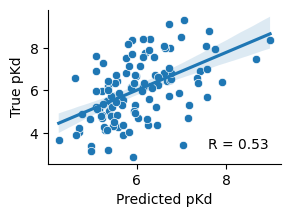

In [ ]:

plt.figure(figsize=(3,2))
r = stats.pearsonr(val_predictions["symbolic_pred"], val_predictions["pKd"])[0]
print("Train R:", r)
sns.scatterplot(val_predictions, x="symbolic_pred", y="pKd", color="tab:blue", label=f'R = {r:.2f}')
sns.regplot(val_predictions, x="symbolic_pred", y="pKd", scatter=False, color="tab:blue")
plt.legend(frameon=False)
plt.xlabel("Predicted pKd")
plt.ylabel("True pKd")
sns.despine()
#plt.savefig("./plots/v2_regression_equation_val_pred_vs_true.svg", dpi=300, bbox_inches='tight')

In [15]:
val_regression_predictions

,complex_filename,y_val,lasso_pred,rf_pred,svr_pred,symbolic_pred,data_type
0,2khs_GSVAYVYKPNNTHEQLLRKSEAQAKKEKLNIWSED,6.443697,6.292161,7.074821,5.705340,6.057033,both
1,2khh_DSGFSFGSK,6.559091,4.497381,4.889349,4.552785,4.482116,both
2,2rnx_STGGVKPHRYKC,3.395774,4.911731,5.207160,4.874541,5.192068,both
3,2vwf_IQPPPVNRNLKPDR,5.060481,5.443103,5.386268,5.270290,4.852495,both
4,2lp8_GCVGRALAAFGDCINR,7.515700,5.955539,5.641272,5.744029,6.166353,both
...,...,...,...,...,...,...,...
328,4poj_KHKILHRLLQD,8.096910,6.043737,6.806464,6.370130,6.600066,alphafold
329,3wdz_KEVDPTGELQ,6.920819,5.584955,5.018274,5.035117,5.092565,alphafold
330,4zsh_KHKILHRLLQD,7.045757,5.993640,6.553089,6.336409,6.717008,alphafold
331,5wuj_FSEEEVRYEIILEKIRGTLKERPDEIAMLFKLLIKDE,6.374688,7.451436,7.708483,7.713211,7.898575,alphafold


# Classification fit

In [5]:
def load_classification_data():
    base_dirs = [
        "/home/er8813ha/immunopeptides/plots_v2_both/classification/",
        "/home/er8813ha/immunopeptides/plots_v2_boltz/classification/",
        "/home/er8813ha/immunopeptides/plots_v2_alphafold/classification/"
    ]
    train_classification_predictions = []
    val_classification_predictions = []
    classification_scaling_parameters = []
    symbolic_equations = []
    for base_dir in base_dirs:
        train_classification_predictions_temp = pd.read_csv(base_dir + "train_predictions.csv")
        val_classification_predictions_temp = pd.read_csv(base_dir + "val_predictions.csv")
        classification_scaling_parameters_temp = pd.read_csv(base_dir + "scaling_params.csv")
        symbolic_equations_temp = pd.read_csv(base_dir + "symbolic_classification_all_equations.csv")
        train_classification_predictions_temp["data_type"] = base_dir.split("/")[-3].split("_v2_")[-1]
        val_classification_predictions_temp["data_type"] = base_dir.split("/")[-3].split("_v2_")[-1]
        classification_scaling_parameters_temp["data_type"] = base_dir.split("/")[-3].split("_v2_")[-1]
        symbolic_equations_temp["data_type"] = base_dir.split("/")[-3].split("_v2_")[-1]

        train_classification_predictions.append(train_classification_predictions_temp)
        val_classification_predictions.append(val_classification_predictions_temp)
        classification_scaling_parameters.append(classification_scaling_parameters_temp)
        symbolic_equations.append(symbolic_equations_temp)

    train_classification_predictions = pd.concat(train_classification_predictions, ignore_index=True)
    val_classification_predictions = pd.concat(val_classification_predictions, ignore_index=True)
    classification_scaling_parameters = pd.concat(classification_scaling_parameters, ignore_index=True)
    symbolic_equations = pd.concat(symbolic_equations, ignore_index=True)

    return train_classification_predictions, val_classification_predictions, classification_scaling_parameters, symbolic_equations

train_classification_predictions, val_classification_predictions, classification_scaling_parameters, symbolic_equations = load_classification_data()

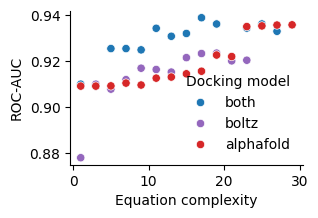

In [ ]:
plt.figure(figsize=(3,2))
sns.scatterplot(symbolic_equations, x="complexity", y="val_auc", hue="data_type", palette=["tab:blue", "tab:purple", "tab:red"])
plt.xlabel("Equation complexity")
plt.ylabel("ROC-AUC")
plt.legend(title="Docking model", loc='lower right', frameon=False)
sns.despine()
#plt.savefig("./plots/v2_classification_equation_complexity_vs_val_auc.svg", dpi=300, bbox_inches='tight')

In [18]:
symbolic_equations.sort_values("val_auc").tail(10)[["data_type", "complexity", "equation"]].values

array([['both', 27,
        '0.71949850272432*alphafold_ipsae_max + 0.4913392*boltz_peptide_plddt - gravy*positively_charged_aa_percent*(gravy + positively_charged_aa_percent + 1.4821618)*(boltz_chain_0_ptm - boltz_confidence_score - isoelectric_point + 1.0118821) + 0.080616548027488'],
       ['both', 11,
        '0.7035934558447*alphafold_ipsae_max + 0.5960651*boltz_peptide_plddt - 0.212465593407681*hydrophobic_aa_percent'],
       ['both', 23,
        '0.73903426507263*alphafold_ipsae_max + 0.5327563*boltz_peptide_plddt - 1.0655126*positively_charged_aa_percent*(gravy + hydrophobic_aa_percent)*(boltz_chain_0_ptm - boltz_confidence_score - isoelectric_point + 0.9003941)'],
       ['alphafold', 23,
        'alphafold_packstat*delta_net_charge_frac**2 + alphafold_peptide_plddt**2 - 1.1880411*negatively_charged_aa_percent*(0.91809845*inter_model_rmsd + 0.91809845*isoelectric_point + positively_charged_aa_percent - 0.52095366556846)'],
       ['alphafold', 25,
        'alphafold_packstat

In [19]:
classification_equation = '0.71949850272432*alphafold_ipsae_max + 0.4913392*boltz_peptide_plddt - gravy*positively_charged_aa_percent*(gravy + positively_charged_aa_percent + 1.4821618)*(boltz_chain_0_ptm - boltz_confidence_score - isoelectric_point + 1.0118821) + 0.080616548027488'

In [20]:
predictions_real = symbolic_predict(real_val, classification_scaling_parameters[classification_scaling_parameters["data_type"] == "both"], classification_equation)
predictions_random = symbolic_predict(random_x_val, classification_scaling_parameters[classification_scaling_parameters["data_type"] == "both"], classification_equation)
predictions_shuffle = symbolic_predict(shuffle_x_val, classification_scaling_parameters[classification_scaling_parameters["data_type"] == "both"], classification_equation)

predictions_random["type"] = "random"
predictions_shuffle["type"] = "shuffle"
predictions_real["type"] = "real"

all_predictions = pd.concat([predictions_real, predictions_random, predictions_shuffle])

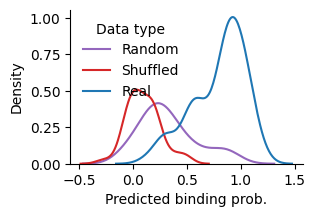

In [ ]:
plt.figure(figsize=(3,2))
sns.kdeplot(all_predictions, x="symbolic_pred", hue="type", palette=["tab:blue", "tab:red", "tab:purple"])
plt.xlabel("Predicted binding prob.")
plt.legend( labels=["Random", "Shuffled", "Real"], title="Data type", loc='upper left', frameon=False)
sns.despine()
#plt.savefig("./plots/v2_classification_equation_val_pred_distribution.svg", dpi=300, bbox_inches='tight')

# Test set combined

In [22]:
real_x_test = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/real_X_test.csv")
real_y_test = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/real_y_test.csv")
shuffle_x_test = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/shuffle_X_test.csv")
random_x_test = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/random_X_test.csv")
real_test = real_x_test.merge(real_y_test, on="complex_filename")

Test R: 0.5203226781098886


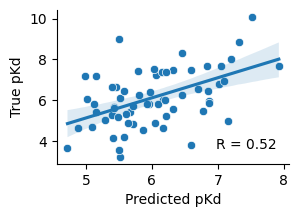

In [ ]:
test_predictions_reg = symbolic_predict(real_test, regression_scaling_parameters[regression_scaling_parameters["data_type"] == "alphafold"], regression_equation)
test_predictions_reg = test_predictions_reg.merge(real_test[["complex_filename", "pKd"]], on="complex_filename")
plt.figure(figsize=(3,2))
r = stats.pearsonr(test_predictions_reg["symbolic_pred"], test_predictions_reg["pKd"])[0]
print("Test R:", r)
sns.scatterplot(test_predictions_reg, x="symbolic_pred", y="pKd", color="tab:blue", label=f'R = {r:.2f}')
sns.regplot(test_predictions_reg, x="symbolic_pred", y="pKd", scatter=False, color="tab:blue")
sns.despine()
plt.legend(frameon=False)
plt.xlabel("Predicted pKd")
plt.ylabel("True pKd")
#plt.savefig("./plots/v2_regression_equation_test_pred_vs_true.svg", dpi=300, bbox_inches='tight')

Test R: 0.2900833715620624


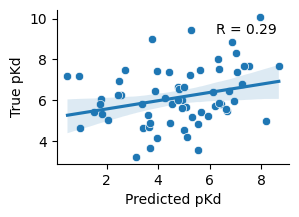

In [ ]:
test_predictions_classification = symbolic_predict(real_test, classification_scaling_parameters[classification_scaling_parameters["data_type"] == "both"], classification_equation)
test_predictions_real = test_predictions_classification.merge(test_predictions_reg, on="complex_filename", suffixes=("_classif", "_reg"))
test_predictions_real["total_pred"] = test_predictions_real["symbolic_pred_classif"] * test_predictions_real["symbolic_pred_reg"]
plt.figure(figsize=(3,2))
r2 = stats.pearsonr(test_predictions_real["total_pred"], test_predictions_real["pKd"])[0]
print("Test R:", r2)
sns.scatterplot(test_predictions_real, x="total_pred", y="pKd", color="tab:blue", label=f'R = {r2:.2f}')
sns.regplot(test_predictions_real, x="total_pred", y="pKd", scatter=False, color="tab:blue")
sns.despine()
plt.legend(frameon=False)
plt.xlabel("Predicted pKd")
plt.ylabel("True pKd")
#plt.savefig("./plots/v2_combined_equation_test_pred_vs_true.svg", dpi=300, bbox_inches='tight')

In [25]:
random_predictions_class = symbolic_predict(random_x_test, classification_scaling_parameters[classification_scaling_parameters["data_type"] == "both"], classification_equation)
shuffle_predictions_class = symbolic_predict(shuffle_x_test, classification_scaling_parameters[classification_scaling_parameters["data_type"] == "both"], classification_equation)
random_predictions_reg = symbolic_predict(random_x_test, regression_scaling_parameters[regression_scaling_parameters["data_type"] == "both"], regression_equation)
shuffle_predictions_reg = symbolic_predict(shuffle_x_test, regression_scaling_parameters[regression_scaling_parameters["data_type"] == "both"], regression_equation)

random_predictions = random_predictions_class.merge(
    random_predictions_reg,
    on="complex_filename",
    suffixes=("_classif", "_reg")
)
shuffle_predictions = shuffle_predictions_class.merge(
    shuffle_predictions_reg,
    on="complex_filename",
    suffixes=("_classif", "_reg")
)
shuffle_predictions["total_pred"] = shuffle_predictions["symbolic_pred_classif"] * shuffle_predictions["symbolic_pred_reg"]
random_predictions["total_pred"] = random_predictions["symbolic_pred_classif"] * random_predictions["symbolic_pred_reg"]

all_predictions = pd.concat([
    test_predictions_real.assign(type="real"),
    random_predictions.assign(type="random"),
    shuffle_predictions.assign(type="shuffle"),
])
all_predictions.head()

,symbolic_pred_classif,complex_filename,symbolic_pred_reg,pKd,total_pred,type
0,1.101566,3h8k_WSADERQRMLVQRKDELLQQARKRFLNK,6.834361,7.677781,7.528502,real
1,0.670718,6fdp_DTSRMEEVD,5.397896,5.259637,3.620466,real
2,1.036731,3sri_KDIGAGPVASCFTTRMSPPQQICLN,7.017539,6.782516,7.275304,real
3,0.861334,2qbw_PQPVDSWV,6.065063,7.251812,5.224044,real
4,0.795295,2n2h_SNAAQLNYLLTDEQIMEDLRTLNKLKS,6.176764,6.031517,4.912351,real


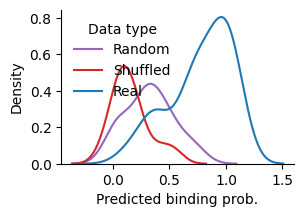

In [ ]:
plt.figure(figsize=(3,2))
sns.kdeplot(all_predictions, x="symbolic_pred_classif", hue="type",  palette=["tab:blue", "tab:red", "tab:purple"])
plt.legend( labels=["Random", "Shuffled", "Real"], title="Data type", loc='upper left', frameon=False)
sns.despine()
plt.xlabel("Predicted binding prob.")
#plt.savefig("./plots/v2_classification_equation_test_pred_distribution.svg", dpi=300, bbox_inches='tight')

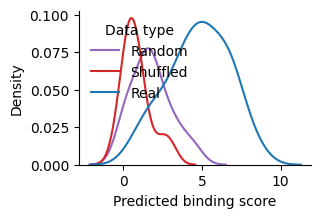

In [ ]:
plt.figure(figsize=(3,2))
sns.kdeplot(all_predictions, x="total_pred", hue="type",  palette=["tab:blue", "tab:red", "tab:purple"])
plt.legend( labels=["Random", "Shuffled", "Real"], title="Data type", loc='upper left', frameon=False)
sns.despine()
plt.xlabel("Predicted binding score")
#plt.savefig("./plots/v2_combined_equation_test_pred_distribution.svg", dpi=300, bbox_inches='tight')

# Boltz AlphFold comparison

,Task,Split,Docking model,n_equations,median_score,best_score
0,Classification,Val,Boltz,12,0.916761,0.923611
1,Classification,Val,AlphaFold,15,0.914602,0.935905
2,Classification,Val,Both,13,0.932151,0.939002
3,Classification,Test,Boltz,12,0.874851,0.883513
4,Classification,Test,AlphaFold,15,0.924134,0.930108
5,Classification,Test,Both,13,0.913082,0.922342
6,Regression,Val,Boltz,15,0.148745,0.187985
7,Regression,Val,AlphaFold,13,0.221849,0.281005
8,Regression,Val,Both,15,0.219005,0.256562
9,Regression,Test,Boltz,15,0.131228,0.216918


,Task,Split,test,statistic,p_value,epsilon_squared
0,Regression,Val,Kruskal-Wallis,11.152440,0.003787,0.228811
1,Regression,Test,Kruskal-Wallis,11.743910,0.002817,0.243598
2,Classification,Val,Kruskal-Wallis,8.639531,0.013303,0.179447
3,Classification,Test,Kruskal-Wallis,26.750181,0.000002,0.668924


,Task,Split,comparison,test,statistic,p_value,median_difference,cliffs_delta,cliffs_delta_magnitude,q_value
0,Regression,Val,Boltz - AlphaFold,Mann-Whitney U,38.0,0.006571,-0.073104,-0.610256,large,0.009856
1,Regression,Val,Boltz - Both,Mann-Whitney U,41.0,0.003230,-0.070260,-0.635556,large,0.009690
2,Regression,Val,AlphaFold - Both,Mann-Whitney U,96.0,0.963248,0.002844,-0.015385,negligible,0.963248
3,Regression,Test,Boltz - AlphaFold,Mann-Whitney U,32.0,0.002751,-0.114780,-0.671795,large,0.008254
4,Regression,Test,Boltz - Both,Mann-Whitney U,55.0,0.018067,-0.083026,-0.511111,large,0.027100
5,Regression,Test,AlphaFold - Both,Mann-Whitney U,135.0,0.088216,0.031754,0.384615,medium,0.088216
6,Classification,Val,Boltz - AlphaFold,Mann-Whitney U,84.0,0.788381,0.002158,-0.066667,negligible,0.788381
7,Classification,Val,Boltz - Both,Mann-Whitney U,19.5,0.001596,-0.015390,-0.750000,large,0.004789
8,Classification,Val,AlphaFold - Both,Mann-Whitney U,57.0,0.065164,-0.017549,-0.415385,medium,0.097747
9,Classification,Test,Boltz - AlphaFold,Mann-Whitney U,0.0,0.000013,-0.049283,-1.000000,large,0.000038


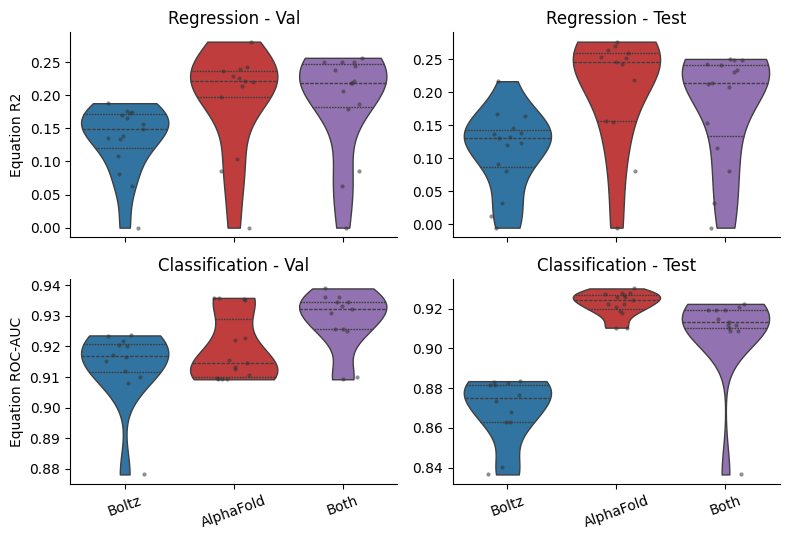

In [13]:
# violinplot of equation distribution performance on val set for Boltz, AlphaFold and Both. 
# also on test set
# Both classification and regression.

from itertools import combinations
from sklearn.metrics import r2_score, roc_auc_score

model_order = ["boltz", "alphafold", "both"]
model_labels = {
    "boltz": "Boltz",
    "alphafold": "AlphaFold",
    "both": "Both",
}
model_palette = {
    "Boltz": "tab:blue",
    "AlphaFold": "tab:red",
    "Both": "tab:purple",
}

_, _, regression_scaling_for_comparison, regression_equations_for_comparison = load_regression_data()
_, _, classification_scaling_for_comparison, classification_equations_for_comparison = load_classification_data()


def _scaling_feature_column(scaling_parameters):
    return "Unnamed: 0" if "Unnamed: 0" in scaling_parameters.columns else scaling_parameters.columns[0]


def _scale_equation_features(df, scaling_parameters):
    scaled = df.copy()
    feature_column = _scaling_feature_column(scaling_parameters)
    for _, row in scaling_parameters.iterrows():
        feature = row[feature_column]
        if feature not in scaled.columns:
            continue
        denominator = row["max"] - row["min"]
        scaled[feature] = 0.0 if denominator == 0 else (scaled[feature] - row["min"]) / denominator
    return scaled


def _predict_equation_scores(df, scaling_parameters, equation):
    scaled = _scale_equation_features(df, scaling_parameters)
    local_env = {column: scaled[column] for column in scaled.columns}
    local_env["np"] = np
    try:
        with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
            predictions = eval(equation, {"__builtins__": {}}, local_env)
    except Exception:
        return np.full(len(scaled), np.nan)
    if np.isscalar(predictions):
        predictions = np.full(len(scaled), predictions)
    predictions = np.asarray(predictions, dtype=float).reshape(-1)
    if len(predictions) != len(scaled):
        return np.full(len(scaled), np.nan)
    return predictions


def _regression_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid_mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if valid_mask.sum() < 2:
        return np.nan, valid_mask.mean()
    return r2_score(y_true[valid_mask], y_pred[valid_mask]), valid_mask.mean()


def _classification_auc(y_true, y_score):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    valid_mask = np.isfinite(y_score)
    if valid_mask.sum() < 2 or len(np.unique(y_true[valid_mask])) < 2:
        return np.nan, valid_mask.mean()
    return roc_auc_score(y_true[valid_mask], y_score[valid_mask]), valid_mask.mean()


def _cliffs_delta(sample_a, sample_b):
    sample_a = np.asarray(sample_a, dtype=float)
    sample_b = np.asarray(sample_b, dtype=float)
    sample_a = sample_a[np.isfinite(sample_a)]
    sample_b = sample_b[np.isfinite(sample_b)]
    if len(sample_a) == 0 or len(sample_b) == 0:
        return np.nan
    differences = sample_a[:, None] - sample_b[None, :]
    return (np.sum(differences > 0) - np.sum(differences < 0)) / differences.size


def _cliffs_delta_magnitude(delta):
    if not np.isfinite(delta):
        return np.nan
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        return "negligible"
    if abs_delta < 0.33:
        return "small"
    if abs_delta < 0.474:
        return "medium"
    return "large"


def _kruskal_epsilon_squared(statistic, n_samples, n_groups):
    if n_samples <= n_groups:
        return np.nan
    return np.clip((statistic - n_groups + 1) / (n_samples - n_groups), 0, 1)


def _benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(len(p_values), np.nan)
    valid_mask = np.isfinite(p_values)
    valid_p_values = p_values[valid_mask]
    if len(valid_p_values) == 0:
        return adjusted

    order = np.argsort(valid_p_values)
    ranked_p_values = valid_p_values[order]
    ranks = np.arange(1, len(ranked_p_values) + 1)
    ranked_adjusted = ranked_p_values * len(ranked_p_values) / ranks
    ranked_adjusted = np.minimum.accumulate(ranked_adjusted[::-1])[::-1]
    ranked_adjusted = np.clip(ranked_adjusted, 0, 1)

    valid_adjusted = np.empty_like(valid_p_values)
    valid_adjusted[order] = ranked_adjusted
    adjusted[valid_mask] = valid_adjusted
    return adjusted


def _validation_equation_performance(equations, task):
    metric_column = "val_r2" if task == "Regression" else "val_auc"
    metric_label = "R2" if task == "Regression" else "ROC-AUC"
    performance = equations.loc[
        equations["data_type"].isin(model_order),
        ["data_type", "equation_index", "complexity", "equation", metric_column],
    ].copy()
    performance = performance.rename(columns={metric_column: "score"})
    performance["Task"] = task
    performance["Split"] = "Val"
    performance["Metric"] = metric_label
    performance["valid_ratio"] = 1.0
    return performance


def _test_equation_performance(equations, scaling_parameters, X_test, y_test, task):
    rows = []
    metric_function = _regression_r2 if task == "Regression" else _classification_auc
    metric_label = "R2" if task == "Regression" else "ROC-AUC"
    for data_type in model_order:
        equations_subset = equations[equations["data_type"] == data_type]
        scaling_subset = scaling_parameters[scaling_parameters["data_type"] == data_type]
        for _, row in equations_subset.iterrows():
            predictions = _predict_equation_scores(X_test, scaling_subset, row["equation"])
            score, valid_ratio = metric_function(y_test, predictions)
            rows.append({
                "data_type": data_type,
                "equation_index": row["equation_index"],
                "complexity": row["complexity"],
                "equation": row["equation"],
                "score": score,
                "Task": task,
                "Split": "Test",
                "Metric": metric_label,
                "valid_ratio": valid_ratio,
            })
    return pd.DataFrame(rows)


if "real_x_test" not in globals():
    data_dir = "/home/er8813ha/immunopeptides/data/x_y_v2"
    real_x_test = pd.read_csv(f"{data_dir}/real_X_test.csv")
    real_y_test = pd.read_csv(f"{data_dir}/real_y_test.csv")
    shuffle_x_test = pd.read_csv(f"{data_dir}/shuffle_X_test.csv")
    random_x_test = pd.read_csv(f"{data_dir}/random_X_test.csv")
    real_test = real_x_test.merge(real_y_test, on="complex_filename")

classification_test = pd.concat(
    [
        real_x_test.assign(label=1),
        random_x_test.assign(label=0),
        shuffle_x_test.assign(label=0),
    ],
    ignore_index=True,
)
classification_test_y = classification_test.pop("label").values

equation_distribution_performance = pd.concat(
    [
        _validation_equation_performance(regression_equations_for_comparison, "Regression"),
        _test_equation_performance(
            regression_equations_for_comparison,
            regression_scaling_for_comparison,
            real_test,
            real_test["pKd"].values,
            "Regression",
        ),
        _validation_equation_performance(classification_equations_for_comparison, "Classification"),
        _test_equation_performance(
            classification_equations_for_comparison,
            classification_scaling_for_comparison,
            classification_test,
            classification_test_y,
            "Classification",
        ),
    ],
    ignore_index=True,
)
equation_distribution_performance["Docking model"] = pd.Categorical(
    equation_distribution_performance["data_type"].map(model_labels),
    categories=[model_labels[data_type] for data_type in model_order],
    ordered=True,
)
equation_distribution_performance["Split"] = pd.Categorical(
    equation_distribution_performance["Split"],
    categories=["Val", "Test"],
    ordered=True,
)

equation_distribution_summary = (
    equation_distribution_performance.dropna(subset=["score"])
    .groupby(["Task", "Split", "Docking model"], observed=True)["score"]
    .agg(n_equations="size", median_score="median", best_score="max")
    .reset_index()
)
display(equation_distribution_summary)

omnibus_rows = []
pairwise_rows = []
model_categories = [model_labels[data_type] for data_type in model_order]

for task in ["Regression", "Classification"]:
    for split in ["Val", "Test"]:
        panel_data = equation_distribution_performance[
            (equation_distribution_performance["Task"] == task)
            & (equation_distribution_performance["Split"] == split)
        ].dropna(subset=["score"])
        grouped_scores = [
            panel_data.loc[panel_data["Docking model"] == model, "score"].values
            for model in model_categories
        ]
        valid_grouped_scores = [scores for scores in grouped_scores if len(scores) > 0]

        if len(valid_grouped_scores) >= 2:
            kruskal_statistic, kruskal_p = stats.kruskal(*valid_grouped_scores)
            epsilon_squared = _kruskal_epsilon_squared(
                kruskal_statistic,
                sum(len(scores) for scores in valid_grouped_scores),
                len(valid_grouped_scores),
            )
        else:
            kruskal_statistic, kruskal_p, epsilon_squared = np.nan, np.nan, np.nan

        omnibus_rows.append({
            "Task": task,
            "Split": split,
            "test": "Kruskal-Wallis",
            "statistic": kruskal_statistic,
            "p_value": kruskal_p,
            "epsilon_squared": epsilon_squared,
        })

        for model_a, model_b in combinations(model_categories, 2):
            scores_a = panel_data.loc[panel_data["Docking model"] == model_a, "score"].values
            scores_b = panel_data.loc[panel_data["Docking model"] == model_b, "score"].values
            if len(scores_a) > 0 and len(scores_b) > 0:
                mannwhitney_statistic, mannwhitney_p = stats.mannwhitneyu(
                    scores_a,
                    scores_b,
                    alternative="two-sided",
                )
                cliffs_delta = _cliffs_delta(scores_a, scores_b)
                median_difference = np.median(scores_a) - np.median(scores_b)
            else:
                mannwhitney_statistic, mannwhitney_p = np.nan, np.nan
                cliffs_delta, median_difference = np.nan, np.nan

            pairwise_rows.append({
                "Task": task,
                "Split": split,
                "comparison": f"{model_a} - {model_b}",
                "test": "Mann-Whitney U",
                "statistic": mannwhitney_statistic,
                "p_value": mannwhitney_p,
                "median_difference": median_difference,
                "cliffs_delta": cliffs_delta,
                "cliffs_delta_magnitude": _cliffs_delta_magnitude(cliffs_delta),
            })

omnibus_equation_distribution_tests = pd.DataFrame(omnibus_rows)
pairwise_equation_distribution_tests = pd.DataFrame(pairwise_rows)
pairwise_equation_distribution_tests["q_value"] = (
    pairwise_equation_distribution_tests
    .groupby(["Task", "Split"], group_keys=False)["p_value"]
    .transform(_benjamini_hochberg)
)

display(omnibus_equation_distribution_tests)
display(pairwise_equation_distribution_tests)

fig, axes = plt.subplots(2, 2, figsize=(8, 5.5), sharex=True)
for row_index, task in enumerate(["Regression", "Classification"]):
    for column_index, split in enumerate(["Val", "Test"]):
        ax = axes[row_index, column_index]
        panel_data = equation_distribution_performance[
            (equation_distribution_performance["Task"] == task)
            & (equation_distribution_performance["Split"] == split)
        ].dropna(subset=["score"])

        sns.violinplot(
            data=panel_data,
            x="Docking model",
            y="score",
            hue="Docking model",
            order=[model_labels[data_type] for data_type in model_order],
            hue_order=[model_labels[data_type] for data_type in model_order],
            palette=model_palette,
            cut=0,
            inner="quartile",
            linewidth=1,
            legend=False,
            ax=ax,
        )
        sns.stripplot(
            data=panel_data,
            x="Docking model",
            y="score",
            order=[model_labels[data_type] for data_type in model_order],
            color="0.2",
            alpha=0.55,
            jitter=0.18,
            size=3,
            ax=ax,
        )

        if task == "Regression":
            ax.set_ylabel("Equation R2" if column_index == 0 else "")
        else:

            ax.set_ylabel("Equation ROC-AUC" if column_index == 0 else "")

        ax.set_xlabel("")
        ax.set_title(f"{task} - {split}")
        omnibus_row = omnibus_equation_distribution_tests[
            (omnibus_equation_distribution_tests["Task"] == task)
            & (omnibus_equation_distribution_tests["Split"] == split)
        ].iloc[0]

        ax.tick_params(axis="x", rotation=20)
        sns.despine(ax=ax)

fig.tight_layout()
plt.savefig("/home/er8813ha/immunopeptides/plots_v2_equation_distribution_comparison.svg", dpi=300, bbox_inches="tight")

# All data

Overall R2: 0.164836249023414


<Axes: xlabel='symbolic_pred_reg', ylabel='pKd'>

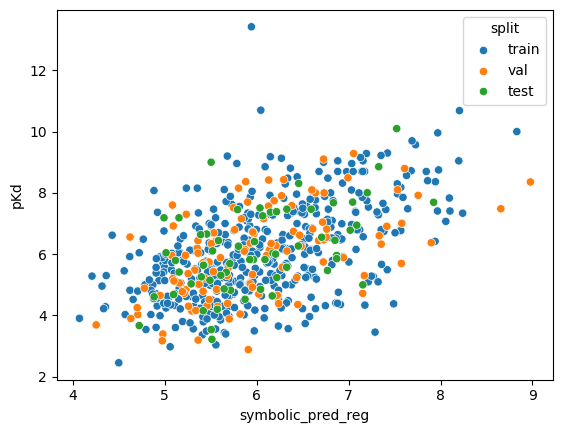

In [37]:
real_train_m = real_train.reset_index()
real_train_m["split"] = "train"
real_val["split"] = "val"
real_test["split"] = "test"
all_data = pd.concat([real_train_m, real_val, real_test])
all_pred_reg = symbolic_predict(all_data, regression_scaling_parameters[regression_scaling_parameters["data_type"] == "both"], regression_equation)
all_pred_class = symbolic_predict(all_data, classification_scaling_parameters[classification_scaling_parameters["data_type"] == "both"], classification_equation)
all_pred = all_pred_class.merge(all_pred_reg, on="complex_filename", suffixes=("_classif", "_reg"))
all_pred["symbolic_pred"] = all_pred["symbolic_pred_classif"] * all_pred["symbolic_pred_reg"]
all_pred = all_pred.merge(all_data[["complex_filename", "pKd", "split"]], on="complex_filename")


r2 = stats.pearsonr(all_pred["symbolic_pred"], all_pred["pKd"])[0]**2
print("Overall R2:", r2)
sns.scatterplot(all_pred, x="symbolic_pred_reg", y="pKd", hue="split")

# Importance

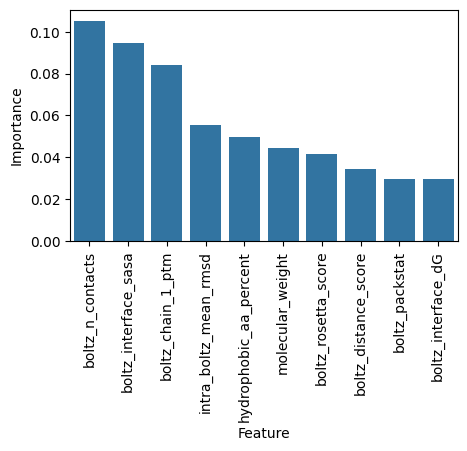

In [38]:
both_regression_importance = pd.read_csv("/home/er8813ha/immunopeptides/plots_v2_both/regression/rf_feature_importance.csv")
alphafold_regression_importance = pd.read_csv("/home/er8813ha/immunopeptides/plots_v2_alphafold/regression/rf_feature_importance.csv")
boltz_regression_importance = pd.read_csv("/home/er8813ha/immunopeptides/plots_v2_boltz/regression/rf_feature_importance.csv")

both_classification_importance = pd.read_csv("/home/er8813ha/immunopeptides/plots_v2_both/classification/rf_feature_importance.csv")
alphafold_classification_importance = pd.read_csv("/home/er8813ha/immunopeptides/plots_v2_alphafold/classification/rf_feature_importance.csv")
boltz_classification_importance = pd.read_csv("/home/er8813ha/immunopeptides/plots_v2_boltz/classification/rf_feature_importance.csv")

plt.figure(figsize=(5,3))
sns.barplot(data=boltz_regression_importance.head(10), x="Feature", y="Importance")
plt.xticks(rotation=90)
plt.show()

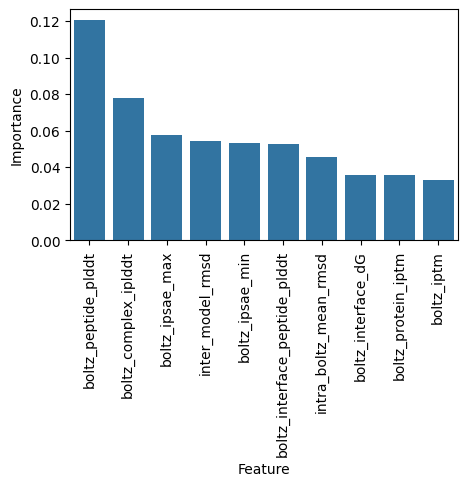

In [39]:
plt.figure(figsize=(5,3))
sns.barplot(data=boltz_classification_importance.head(10), x="Feature", y="Importance")
plt.xticks(rotation=90)
plt.show()